Load dataset

In [1]:
import pandas as pd

df_uci = pd.read_csv("blood_transfusion.csv")

df_uci.head()

,Recency (months),Frequency (times),Monetary (c.c. blood),Time (months),whether he/she donated blood in March 2007
0,2,50,12500,98,1
1,0,13,3250,28,1
2,1,16,4000,35,1
3,2,20,5000,45,1
4,1,24,6000,77,0


Dataset shape

In [2]:
df_uci.shape

(748, 5)

Structure

In [3]:
df_uci.info()

<class 'pandas.DataFrame'>
RangeIndex: 748 entries, 0 to 747
Data columns (total 5 columns):
 #   Column                                      Non-Null Count  Dtype
---  ------                                      --------------  -----
 0   Recency (months)                            748 non-null    int64
 1   Frequency (times)                           748 non-null    int64
 2   Monetary (c.c. blood)                       748 non-null    int64
 3   Time (months)                               748 non-null    int64
 4   whether he/she donated blood in March 2007  748 non-null    int64
dtypes: int64(5)
memory usage: 29.3 KB


In [4]:
df_uci.columns

Index(['Recency (months)', 'Frequency (times)', 'Monetary (c.c. blood)',
       'Time (months)', 'whether he/she donated blood in March 2007'],
      dtype='str')

In [5]:
target_col = "whether he/she donated blood in March 2007"

df_uci[target_col].value_counts()

whether he/she donated blood in March 2007
0    570
1    178
Name: count, dtype: int64

In [6]:
df_uci = df_uci.rename(columns={
    "Recency (months)": "Recency",
    "Frequency (times)": "Frequency",
    "Monetary (c.c. blood)": "Monetary",
    "Time (months)": "Time",
    "whether he/she donated blood in March 2007": "Target"
})

df_uci.head()

,Recency,Frequency,Monetary,Time,Target
0,2,50,12500,98,1
1,0,13,3250,28,1
2,1,16,4000,35,1
3,2,20,5000,45,1
4,1,24,6000,77,0


Target distribution

<Axes: xlabel='Target'>

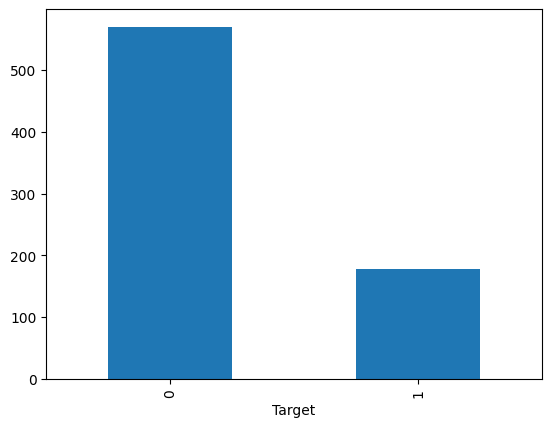

In [7]:
df_uci["Target"].value_counts()

df_uci["Target"].value_counts().plot(kind="bar")

Summary statistics

In [8]:
df_uci.describe()

,Recency,Frequency,Monetary,Time,Target
count,748.000000,748.000000,748.000000,748.000000,748.000000
mean,9.506684,5.514706,1378.676471,34.282086,0.237968
std,8.095396,5.839307,1459.826781,24.376714,0.426124
min,0.000000,1.000000,250.000000,2.000000,0.000000
25%,2.750000,2.000000,500.000000,16.000000,0.000000
50%,7.000000,4.000000,1000.000000,28.000000,0.000000
75%,14.000000,7.000000,1750.000000,50.000000,0.000000
max,74.000000,50.000000,12500.000000,98.000000,1.000000


Correlation heatmap

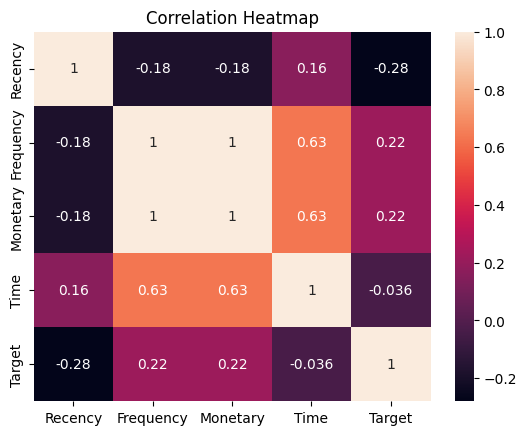

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(df_uci.corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()

# Phase 17A (re-run) — Logistic Regression on UCI dataset

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

X = df_uci[["Recency", "Frequency", "Time"]]
y = df_uci["Target"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

model = LogisticRegression(class_weight="balanced", max_iter=1000)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

Accuracy: 0.72
[[78 36]
 [ 6 30]]
              precision    recall  f1-score   support

           0       0.93      0.68      0.79       114
           1       0.45      0.83      0.59        36

    accuracy                           0.72       150
   macro avg       0.69      0.76      0.69       150
weighted avg       0.81      0.72      0.74       150

ROC-AUC: 0.7846003898635477


# Phase 17B — Random Forest (UCI Dataset)

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

X = df_uci[["Recency", "Frequency", "Time"]]
y = df_uci["Target"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

rf_model = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)
y_prob = rf_model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

Accuracy: 0.72
[[92 22]
 [20 16]]
              precision    recall  f1-score   support

           0       0.82      0.81      0.81       114
           1       0.42      0.44      0.43        36

    accuracy                           0.72       150
   macro avg       0.62      0.63      0.62       150
weighted avg       0.73      0.72      0.72       150

ROC-AUC: 0.7218567251461987


# Phase 17C — XGBoost (UCI Dataset)

In [12]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=4,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train, y_train)

y_pred = xgb_model.predict(X_test)
y_prob = xgb_model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

Accuracy: 0.7866666666666666
[[101  13]
 [ 19  17]]
              precision    recall  f1-score   support

           0       0.84      0.89      0.86       114
           1       0.57      0.47      0.52        36

    accuracy                           0.79       150
   macro avg       0.70      0.68      0.69       150
weighted avg       0.78      0.79      0.78       150

ROC-AUC: 0.7470760233918128


# Final Availability Model Comparison Table

In [14]:
import pandas as pd

comparison_df = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        0.72,
        0.72,
        0.7867
    ],
    "Precision": [
        0.45,
        0.42,
        0.57
    ],
    "Recall": [
        0.83,
        0.44,
        0.47
    ],
    "F1_Score": [
        0.59,
        0.43,
        0.52
    ],
    "ROC_AUC": [
        0.7846,
        0.7219,
        0.7471
    ]
})

comparison_df.sort_values(
    by=["F1_Score", "ROC_AUC", "Accuracy"],
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1_Score,ROC_AUC
0,Logistic Regression,0.7200,0.45,0.83,0.59,0.7846
2,XGBoost,0.7867,0.57,0.47,0.52,0.7471
1,Random Forest,0.7200,0.42,0.44,0.43,0.7219
